# Brain-Tumor Classifiers - Full Comparison

Loads **all 8 trained models** (4 architectures x {pretrained, scratch}) and evaluates
them on the shared Roboflow test set, so the team can compare every model in one place.

| architecture | pretrained ckpt | scratch ckpt | input | loss / decision |
|---|---|---|---|---|
| SqueezeNet   | `squeezenet.pt`          | `squeezenet_s.pt`        | 227px | CrossEntropy / argmax |
| ResNet-18    | `resnet18.pt`            | `resnet_custom.pt`       | 227px | CrossEntropy / argmax |
| EfficientNet | `efficientnet.pt`        | `efficientnet_scratch.pt`| 224px | CrossEntropy / argmax |
| GoogLeNet    | `googlenet_pretrained.pth`| `googlenet_scratch.pth` | 224px | BCEWithLogits / sigmoid>=0.5 |

**The model architectures below are copied verbatim from each teammate's branch** -
nothing about their characteristics is changed. Each architecture is rebuilt exactly
as it was trained, then its saved `state_dict` is loaded.

> Note: `resnet_custom.pt` (ResNet from scratch) has not been trained yet, so that one
> row is skipped automatically until the checkpoint exists.

## 0. Setup & configuration

Auto-detects the data + checkpoint locations so the notebook runs on Kaggle (datasets
mounted under `/kaggle/input`) or locally (`brain-Tumor-1/` + `comparison_checkpoints/`).

In [1]:
import os, glob, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torchvision.models import (
    squeezenet1_0,
    resnet18,
    efficientnet_b0,
    googlenet, GoogLeNet_Weights,
)
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def _glob_first(name, kind="file"):
    """Recursively find a file/dir by name under the usual Kaggle/local roots.

    Works no matter how a dataset is mounted (/kaggle/input/<name>,
    /kaggle/input/datasets/<owner>/<name>, a local folder, ...).
    """
    for base in ("/kaggle/input", "/kaggle/working", "."):
        if not os.path.isdir(base):
            continue
        for hit in sorted(glob.glob(os.path.join(base, "**", name), recursive=True)):
            if (kind == "file" and os.path.isfile(hit)) or (kind == "dir" and os.path.isdir(hit)):
                return hit
    return None

# Long's preprocess.py supplies ImagePreprocessor (the shared train/test transforms).
pp = _glob_first("preprocess.py", "file")
assert pp, "preprocess.py not found - attach the 'brain-tumor-detection-support' dataset"
sys.path.insert(0, os.path.dirname(pp))
from preprocess import ImagePreprocessor

# Test images: <DATA_ROOT>/test/<class>/*.png  (ImageFolder layout).
test_dir = _glob_first("test", "dir")
assert test_dir, "test/ folder not found - attach the 'brain-tumor-roboflow-v1' dataset"
DATA_ROOT = os.path.dirname(test_dir)

# Checkpoints (.pt/.pth) are resolved by filename, recursively, wherever attached.
# Returns None if a checkpoint is missing -> that model is skipped (no error).
def find_ckpt(fname):
    for base in ("comparison_checkpoints", "/kaggle/input", "/kaggle/working", "."):
        if not os.path.isdir(base):
            continue
        direct = os.path.join(base, fname)
        if os.path.isfile(direct):
            return direct
        hits = sorted(glob.glob(os.path.join(base, "**", fname), recursive=True))
        if hits:
            return hits[0]
    return None

print("preprocess.py:", pp)
print("DATA_ROOT    :", DATA_ROOT)

device: cuda
preprocess.py: /kaggle/input/datasets/ragtxt/brain-tumor-detection-support/preprocess.py
DATA_ROOT    : /kaggle/input/datasets/ragtxt/brain-tumor-roboflow-v1


## 1. Model definitions (verbatim)

The two hand-written architectures are imported from their own modules rather than
pasted in, so this notebook stays lean: GoogLeNet from `googlenet.py` (GoogLeNet branch)
and the from-scratch `SmallResNet` from `small_resnet.py` (ResNet branch). The other six
models are plain torchvision builders, defined in the registry below.

In [2]:
# GoogLeNet (Inception v1) lives verbatim in googlenet.py (GoogLeNet branch, by the
# GoogLeNet owner). Instead of pasting the whole module in, we locate the file wherever
# it is attached and import it - keeps this notebook lean.
gnet_py = _glob_first("googlenet.py", "file")
assert gnet_py, "googlenet.py not found - attach the dataset that ships it (brain-tumor-checkpoints)"
sys.path.insert(0, os.path.dirname(gnet_py))
from googlenet import GoogLeNet, InceptionModule, AuxiliaryClassifier
print("googlenet.py:", gnet_py)

googlenet.py: /kaggle/input/datasets/ragtxt/brain-tumor-checkpoints/googlenet.py


In [3]:
# SmallResNet (hand-written from-scratch ResNet, ResNet branch) lives verbatim in
# small_resnet.py. Instead of pasting it in, we locate the file wherever it is attached
# and import it - keeps this notebook lean.
sr_py = _glob_first("small_resnet.py", "file")
assert sr_py, "small_resnet.py not found - attach the dataset that ships it (brain-tumor-checkpoints)"
sys.path.insert(0, os.path.dirname(sr_py))
from small_resnet import SmallResNet, BasicBlock
print("small_resnet.py:", sr_py)

small_resnet.py: /kaggle/input/datasets/ragtxt/brain-tumor-checkpoints/small_resnet.py


## 2. Shared test set

One test set, loaded at each model's native input size (227px or 224px). Labels come
from `ImageFolder` (alphabetical class order), identical for every model, so accuracy
is directly comparable.

In [4]:
SIZES = [(227, 227), (224, 224)]
test_loaders = {}
for size in SIZES:
    tf = ImagePreprocessor(size=size).test_transform
    ds = ImageFolder(os.path.join(DATA_ROOT, "test"), transform=tf)
    test_loaders[size] = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=False)

CLASSES = test_loaders[SIZES[0]].dataset.classes
NUM_CLASSES = len(CLASSES)
POS_LABEL = NUM_CLASSES - 1            # second class (alphabetical) = positive (Tumor)
print("classes:", CLASSES, "| positive label:", CLASSES[POS_LABEL],
      "| test images:", len(test_loaders[SIZES[0]].dataset))

classes: ['NoTumor', 'Tumor'] | positive label: Tumor | test images: 23


## 3. Evaluation helper


In [5]:
results, conf_mats = [], {}

@torch.no_grad()
def score(model, name, variant, head, size):
    """Run the already-loaded model over the test set and record its metrics.

    head: "ce"  -> CrossEntropy model, argmax over the 2 class logits
          "bce" -> single-logit model (GoogLeNet), sigmoid >= 0.5
    """
    model.to(device).eval()
    y_true, y_pred = [], []
    for x, y in test_loaders[size]:
        out = model(x.to(device))
        if isinstance(out, tuple):                 # GoogLeNet may return (main, aux1, aux2)
            out = out[0]
        if head == "ce":
            p = out.argmax(1)
        else:
            p = (torch.sigmoid(out) >= 0.5).long().squeeze(1)
        y_pred += p.cpu().tolist()
        y_true += y.tolist()
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = float((y_true == y_pred).mean())
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=POS_LABEL, zero_division=0)
    tag = f"{name} ({variant})"
    conf_mats[tag] = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    params = sum(p.numel() for p in model.parameters())
    results.append({
        "model": name, "variant": variant, "params": params,
        "input": f"{size[0]}px", "loss": head.upper(),
        "accuracy": round(acc, 4), "precision": round(float(prec), 4),
        "recall": round(float(rec), 4), "f1": round(float(f1), 4),
    })
    print(f"OK    {tag:26s}  acc={acc:.4f}  params={params:,}")
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()


## 4. Load each trained checkpoint & evaluate


In [6]:
# Each block: build the empty architecture, load YOUR trained weights from
# comparison_checkpoints, then score it. No registry, no builder dispatch.

# ---- SqueezeNet  (227px, CrossEntropy head) ----
m = squeezenet1_0(weights=None)
m.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
m.load_state_dict(torch.load(find_ckpt("squeezenet_pretrained.pt"), map_location=device))
score(m, "SqueezeNet", "pretrained", "ce", (227, 227))

m = squeezenet1_0(weights=None)
m.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
m.load_state_dict(torch.load(find_ckpt("squeezenet_s.pt"), map_location=device))
score(m, "SqueezeNet", "scratch", "ce", (227, 227))

# ---- ResNet  (227px, CrossEntropy head) ----
m = resnet18(weights=None)
m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
m.load_state_dict(torch.load(find_ckpt("resnet18_pretrained.pt"), map_location=device))
score(m, "ResNet-18", "pretrained", "ce", (227, 227))

m = SmallResNet(NUM_CLASSES)                         # hand-written from-scratch ResNet
m.load_state_dict(torch.load(find_ckpt("resnet_scratch.pt"), map_location=device))
score(m, "ResNet", "scratch", "ce", (227, 227))

# ---- EfficientNet  (224px, CrossEntropy head) ----
m = efficientnet_b0(weights=None)
m.classifier[1] = nn.Linear(1280, NUM_CLASSES)
m.load_state_dict(torch.load(find_ckpt("efficientnet_pretrained.pt"), map_location=device))
score(m, "EfficientNet", "pretrained", "ce", (224, 224))

m = efficientnet_b0(weights=None)
m.classifier[1] = nn.Linear(1280, NUM_CLASSES)
m.load_state_dict(torch.load(find_ckpt("efficientnet_scratch.pt"), map_location=device))
score(m, "EfficientNet", "scratch", "ce", (224, 224))

# ---- GoogLeNet  (224px, BCE single-logit head) ----
# pretrained build keeps weights=IMAGENET1K_V1 so transform_input matches training
m = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
m.fc = nn.Linear(m.fc.in_features, 1)
m.aux1.fc2 = nn.Linear(m.aux1.fc2.in_features, 1)
m.aux2.fc2 = nn.Linear(m.aux2.fc2.in_features, 1)
m.load_state_dict(torch.load(find_ckpt("googlenet_pretrained.pth"), map_location=device))
score(m, "GoogLeNet", "pretrained", "bce", (224, 224))

m = GoogLeNet(lr=1e-4, weight_decay=1e-4, dropout_prob=0.4, aux_weight=0.3)
m.load_state_dict(torch.load(find_ckpt("googlenet_scratch.pth"), map_location=device))
score(m, "GoogLeNet", "scratch", "bce", (224, 224))

print(f"\nevaluated {len(results)} / 8 models (positive class = '{CLASSES[POS_LABEL]}')")


OK    SqueezeNet (pretrained)     acc=0.7391  params=736,450
OK    SqueezeNet (scratch)        acc=0.6087  params=736,450
OK    ResNet-18 (pretrained)      acc=0.8261  params=11,177,538
OK    ResNet (scratch)            acc=0.8261  params=79,442
OK    EfficientNet (pretrained)   acc=0.8261  params=4,010,110
OK    EfficientNet (scratch)      acc=0.6087  params=4,010,110
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 168MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


OK    GoogLeNet (pretrained)      acc=0.8261  params=9,932,963
OK    GoogLeNet (scratch)         acc=0.8696  params=10,306,355

evaluated 8 / 8 models (positive class = 'Tumor')


## 5. Results table

Sorted by test accuracy. `precision` / `recall` / `f1` are for the positive (Tumor) class.

In [7]:
if results:
    df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
    show = df.copy()
    show["params"] = show["params"].map(lambda n: f"{n:,}")
    print(show.to_string(index=False))
else:
    df = pd.DataFrame()
    show = df
    print("No models were evaluated - no checkpoints were found under the search roots.")
    print("Attach the checkpoint dataset (the 8 .pt/.pth files) and re-run to fill this table.")
show

       model    variant     params input loss  accuracy  precision  recall     f1
   GoogLeNet    scratch 10,306,355 224px  BCE    0.8696     0.8235  1.0000 0.9032
      ResNet    scratch     79,442 227px   CE    0.8261     0.7778  1.0000 0.8750
EfficientNet pretrained  4,010,110 224px   CE    0.8261     0.9167  0.7857 0.8462
   ResNet-18 pretrained 11,177,538 227px   CE    0.8261     0.7778  1.0000 0.8750
   GoogLeNet pretrained  9,932,963 224px  BCE    0.8261     0.9167  0.7857 0.8462
  SqueezeNet pretrained    736,450 227px   CE    0.7391     0.7222  0.9286 0.8125
  SqueezeNet    scratch    736,450 227px   CE    0.6087     0.6087  1.0000 0.7568
EfficientNet    scratch  4,010,110 224px   CE    0.6087     0.6087  1.0000 0.7568


,model,variant,params,input,loss,accuracy,precision,recall,f1
0,GoogLeNet,scratch,"10,306,355",224px,BCE,0.8696,0.8235,1.0000,0.9032
1,ResNet,scratch,"79,442",227px,CE,0.8261,0.7778,1.0000,0.8750
2,EfficientNet,pretrained,"4,010,110",224px,CE,0.8261,0.9167,0.7857,0.8462
3,ResNet-18,pretrained,"11,177,538",227px,CE,0.8261,0.7778,1.0000,0.8750
4,GoogLeNet,pretrained,"9,932,963",224px,BCE,0.8261,0.9167,0.7857,0.8462
5,SqueezeNet,pretrained,"736,450",227px,CE,0.7391,0.7222,0.9286,0.8125
6,SqueezeNet,scratch,"736,450",227px,CE,0.6087,0.6087,1.0000,0.7568
7,EfficientNet,scratch,"4,010,110",224px,CE,0.6087,0.6087,1.0000,0.7568


## 6. Plots

Accuracy ranking (pretrained vs scratch) and a confusion-matrix grid.

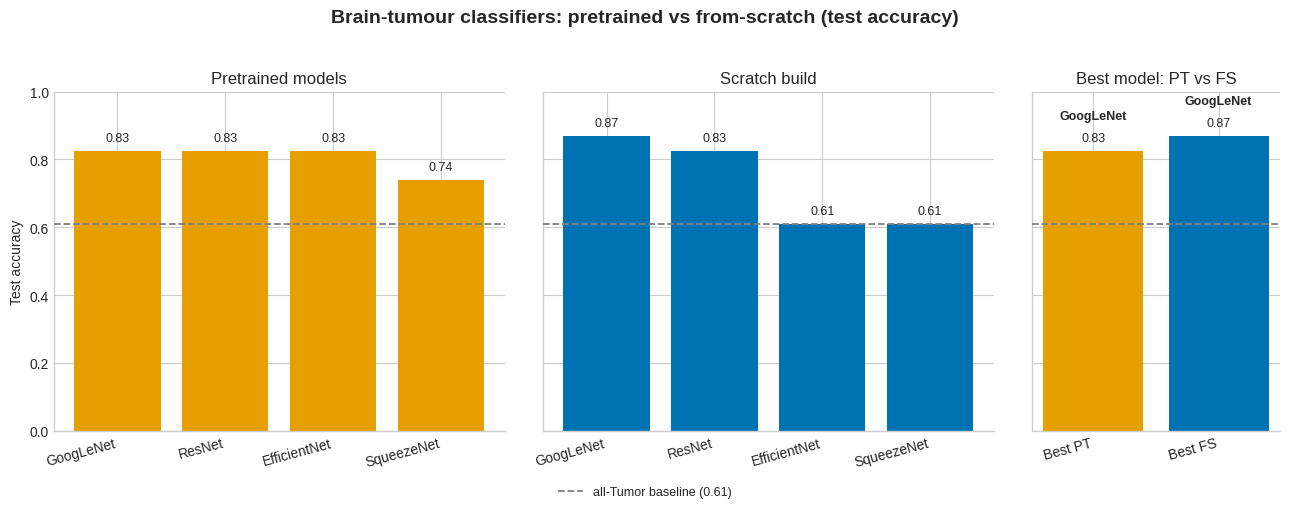

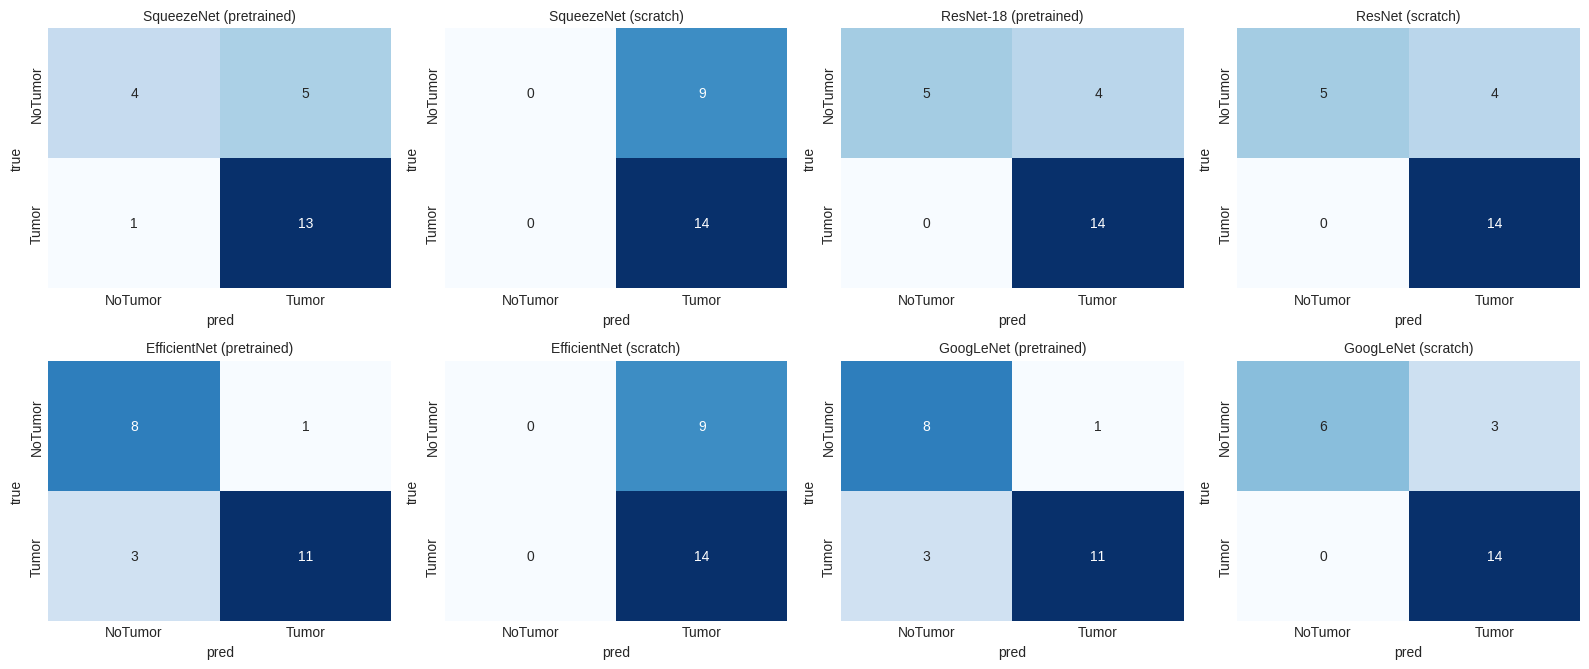

In [8]:
if results:
    plt.style.use("seaborn-v0_8-whitegrid")

    # ---- choose the metric (swap to "f1" to compare F1 instead of accuracy) ----
    METRIC = "accuracy"
    METRIC_LABEL = "Test accuracy" if METRIC == "accuracy" else "Test " + METRIC.upper()

    # ---- fixed model order; PT ResNet is "ResNet-18", FS is "ResNet" -> normalise ----
    ORDER = ["GoogLeNet", "ResNet", "EfficientNet", "SqueezeNet"]
    fam = lambda name: name.split("-")[0].strip()

    # ---- pull the freshly-evaluated numbers straight out of `results` (dynamic) ----
    score = {(fam(r["model"]), r["variant"]): r[METRIC] for r in results}
    pt_vals = [score.get((m, "pretrained"), np.nan) for m in ORDER]
    fs_vals = [score.get((m, "scratch"),    np.nan) for m in ORDER]

    # ---- all-Tumor baseline = positive-class (Tumor) base rate on the test set ----
    targets   = np.array(test_loaders[SIZES[0]].dataset.targets)
    baseline  = float((targets == POS_LABEL).mean())
    BASE_LABEL = f"all-Tumor baseline ({baseline:.2f})"

    PT_COLOR, FS_COLOR = "#E69F00", "#0072B2"

    def _annotate(ax, xs, vals):
        for x, v in zip(xs, vals):
            if np.isfinite(v):
                ax.text(x, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

    def _style(ax, left=False):
        ax.set_ylim(0, 1.0)
        line = ax.axhline(baseline, ls="--", lw=1.3, color="grey",
                          label=BASE_LABEL, zorder=3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for t in ax.get_xticklabels():
            t.set_rotation(15); t.set_ha("right")
        if left:
            ax.set_ylabel(METRIC_LABEL)
        return line

    fig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, figsize=(13, 5), sharey=True,
        gridspec_kw={"width_ratios": [1, 1, 0.55]})

    x = np.arange(len(ORDER))

    # PANEL 1 - pretrained
    ax1.bar(x, pt_vals, color=PT_COLOR)
    ax1.set_xticks(x); ax1.set_xticklabels(ORDER)
    ax1.set_title("Pretrained models")
    _annotate(ax1, x, pt_vals)
    base_handle = _style(ax1, left=True)

    # PANEL 2 - from scratch
    ax2.bar(x, fs_vals, color=FS_COLOR)
    ax2.set_xticks(x); ax2.set_xticklabels(ORDER)
    ax2.set_title("Scratch build")
    _annotate(ax2, x, fs_vals)
    _style(ax2)

    # PANEL 3 - best PT vs best FS (winning model name annotated above each bar)
    def _best(vals):
        arr = np.array(vals, dtype=float)
        if not np.isfinite(arr).any():
            return "-", np.nan
        i = int(np.nanargmax(arr))
        return ORDER[i], float(arr[i])

    pt_name, pt_best = _best(pt_vals)
    fs_name, fs_best = _best(fs_vals)
    xb = np.arange(2)
    ax3.bar(xb, [pt_best, fs_best], color=[PT_COLOR, FS_COLOR])
    ax3.set_xticks(xb); ax3.set_xticklabels(["Best PT", "Best FS"])
    ax3.set_title("Best model: PT vs FS")
    for x0, v, nm in zip(xb, [pt_best, fs_best], [pt_name, fs_name]):
        if np.isfinite(v):
            ax3.text(x0, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
            ax3.text(x0, v + 0.085, nm, ha="center", va="bottom",
                     fontsize=9, fontweight="bold")
    _style(ax3)

    fig.legend(handles=[base_handle], loc="lower center",
               bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
    fig.suptitle("Brain-tumour classifiers: pretrained vs from-scratch (test accuracy)",
                 fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ---- per-model confusion matrices ----
    n = len(conf_mats); cols = 4; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (tag, cm) in zip(axes, conf_mats.items()):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
        ax.set_title(tag, fontsize=10); ax.set_xlabel("pred"); ax.set_ylabel("true")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("no results to plot - no checkpoints were found")


## 7. Reporting: PT vs FS tables, improvement, best-model error analysis


In [ ]:
if results:
    rep = pd.DataFrame(results).copy()
    rep["family"] = rep["model"].str.split("-").str[0].str.strip()
    cols = ["family", "model", "params", "accuracy", "precision", "recall", "f1"]

    pt_table = (rep[rep.variant == "pretrained"][cols]
                .sort_values("accuracy", ascending=False).reset_index(drop=True))
    fs_table = (rep[rep.variant == "scratch"][cols]
                .sort_values("accuracy", ascending=False).reset_index(drop=True))

    def _show(t):
        s = t.copy(); s["params"] = s["params"].map(lambda n: f"{n:,}")
        return s.to_string(index=False)

    print("=== PRETRAINED (4 models) ===")
    print(_show(pt_table))
    print("
=== FROM SCRATCH (4 models) ===")
    print(_show(fs_table))
else:
    pt_table = fs_table = pd.DataFrame()
    print("No results - attach the checkpoint dataset and re-run from section 4.")


In [ ]:
if results:
    piv = rep.pivot_table(index="family", columns="variant", values="accuracy")
    piv["abs_gain_pts"] = (piv.get("pretrained", np.nan) - piv.get("scratch", np.nan)) * 100
    piv["rel_gain_%"]   = 100 * (piv.get("pretrained", np.nan) - piv.get("scratch", np.nan)) / piv.get("scratch", np.nan)
    piv = piv.sort_values("abs_gain_pts", ascending=False)

    print("Does pretraining beat training from scratch? (accuracy)")
    print(piv.round(4).to_string())

    mean_abs = piv["abs_gain_pts"].mean()
    n_better = int((piv["abs_gain_pts"] > 0).sum())
    print(f"
Pretrained wins in {n_better}/{len(piv)} families; "
          f"mean accuracy gain = {mean_abs:+.2f} pts")
    piv


In [ ]:
if results:
    best = max(results, key=lambda r: r["accuracy"])
    tag  = f"{best['model']} ({best['variant']})"
    cm   = np.asarray(conf_mats[tag])
    tn, fp = int(cm[0, 0]), int(cm[0, 1])
    fn, tp = int(cm[1, 0]), int(cm[1, 1])

    acc         = (tp + tn) / cm.sum()
    precision   = tp / (tp + fp) if (tp + fp) else float("nan")
    recall      = tp / (tp + fn) if (tp + fn) else float("nan")   # sensitivity
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")
    fnr         = fn / (tp + fn) if (tp + fn) else float("nan")   # missed tumours
    fpr         = fp / (tn + fp) if (tn + fp) else float("nan")   # false alarms

    print(f"Best model: {tag}")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  accuracy    = {acc:.4f}")
    print(f"  precision   = {precision:.4f}")
    print(f"  recall/sens = {recall:.4f}")
    print(f"  specificity = {specificity:.4f}")
    print(f"  FN rate (missed tumours) = {fnr:.4f}")
    print(f"  FP rate (false alarms)   = {fpr:.4f}")

    plt.figure(figsize=(4.6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES,
                annot_kws={"size": 14})
    plt.title(f"Best model: {tag}", fontsize=11)
    plt.xlabel("predicted"); plt.ylabel("true")
    plt.tight_layout()
    plt.savefig("best_model_confusion.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No results - nothing to analyse.")
